In [18]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense,Flatten,Embedding

In [19]:
docs = ['go pakistan',
		'pakistan pakistan',
		'hip hip hurray',
		'jeetega bhai jeetega pakistan jeetega',
		'this is not good',
		'kohli kohli',
		'babar babar',
		'dhoni dhoni',
		'why so serious boy',
		'inquilab zindabad']

In [20]:
tokenizer = Tokenizer()

In [21]:
tokenizer.fit_on_texts(docs)

In [22]:
tokenizer.word_index

{'pakistan': 1,
 'jeetega': 2,
 'hip': 3,
 'kohli': 4,
 'babar': 5,
 'dhoni': 6,
 'go': 7,
 'hurray': 8,
 'bhai': 9,
 'this': 10,
 'is': 11,
 'not': 12,
 'good': 13,
 'why': 14,
 'so': 15,
 'serious': 16,
 'boy': 17,
 'inquilab': 18,
 'zindabad': 19}

In [23]:
sequences = tokenizer.texts_to_sequences(docs)
sequences

[[7, 1],
 [1, 1],
 [3, 3, 8],
 [2, 9, 2, 1, 2],
 [10, 11, 12, 13],
 [4, 4],
 [5, 5],
 [6, 6],
 [14, 15, 16, 17],
 [18, 19]]

In [24]:
from keras.utils import pad_sequences
sequences = pad_sequences(sequences,padding='post')
sequences

array([[ 7,  1,  0,  0,  0],
       [ 1,  1,  0,  0,  0],
       [ 3,  3,  8,  0,  0],
       [ 2,  9,  2,  1,  2],
       [10, 11, 12, 13,  0],
       [ 4,  4,  0,  0,  0],
       [ 5,  5,  0,  0,  0],
       [ 6,  6,  0,  0,  0],
       [14, 15, 16, 17,  0],
       [18, 19,  0,  0,  0]], dtype=int32)

In [25]:
model = Sequential()
model.add(Embedding(20,output_dim=2,input_length=5))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile('adam','accuracy')

In [27]:
pred = model.predict(sequences)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
[[[ 0.03501881 -0.0282181 ]
  [-0.00423205  0.00457644]
  [ 0.04290452  0.00039218]
  [ 0.04290452  0.00039218]
  [ 0.04290452  0.00039218]]

 [[-0.00423205  0.00457644]
  [-0.00423205  0.00457644]
  [ 0.04290452  0.00039218]
  [ 0.04290452  0.00039218]
  [ 0.04290452  0.00039218]]

 [[-0.04418181 -0.04073007]
  [-0.04418181 -0.04073007]
  [ 0.00691961 -0.03478724]
  [ 0.04290452  0.00039218]
  [ 0.04290452  0.00039218]]

 [[-0.02498276 -0.00056566]
  [-0.04314376  0.00684004]
  [-0.02498276 -0.00056566]
  [-0.00423205  0.00457644]
  [-0.02498276 -0.00056566]]

 [[ 0.01771664  0.01786796]
  [ 0.01508969  0.00919155]
  [ 0.0338498   0.04252261]
  [-0.04037777  0.00466377]
  [ 0.04290452  0.00039218]]

 [[-0.02753886  0.01650314]
  [-0.02753886  0.01650314]
  [ 0.04290452  0.00039218]
  [ 0.04290452  0.00039218]
  [ 0.04290452  0.00039218]]

 [[ 0.01155342 -0.00785086]
  [ 0.01155342 -0.00785086]
  [ 0.04290452  0.00039218]
  [ 0.04290452  0.0003921

In [28]:
from keras.datasets import imdb
from keras.utils import pad_sequences
from keras import Sequential
from keras.layers import Dense,SimpleRNN,Embedding,Flatten, Input

In [29]:
(X_train,y_train),(X_test,y_test) = imdb.load_data()

In [30]:
X_train = pad_sequences(X_train,padding='post',maxlen=50)
X_test = pad_sequences(X_test,padding='post',maxlen=50)

In [31]:
X_train.shape

(25000, 50)

In [49]:
model = Sequential()
model.add(Input(shape=(50,)))
model.add(Embedding(10000, 2))
model.add(SimpleRNN(32,return_sequences=False))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 50, 2)          │        20,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,153 (82.63 KB)

 Trainable params: 21,153 (82.63 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
#add call back to stop training when validation accuracy is not improving for 3 epochs

# Keep all token IDs inside the embedding vocabulary range [0, 9999]
X_train = np.where(X_train < 10000, X_train, 2)
X_test = np.where(X_test < 10000, X_test, 2)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - acc: 0.6347 - loss: 0.6069 - val_acc: 0.7886 - val_loss: 0.4591
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - acc: 0.8260 - loss: 0.3922 - val_acc: 0.8109 - val_loss: 0.4109
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - acc: 0.8653 - loss: 0.3224 - val_acc: 0.7969 - val_loss: 0.4486
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - acc: 0.8906 - loss: 0.2741 - val_acc: 0.8087 - val_loss: 0.4476
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - acc: 0.9093 - loss: 0.2352 - val_acc: 0.7983 - val_loss: 0.5023
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - acc: 0.9206 - loss: 0.2065 - val_acc: 0.7954 - val_loss: 0.5500
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - acc: 0.9348 - loss: 0.1795 - val_acc: 0.7770 - val_loss: 0.6309
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - acc: 0.9456 - loss: 0.1530 - val_acc: 0.7774 - val_loss: 0.6672
Epoch 9/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - ac

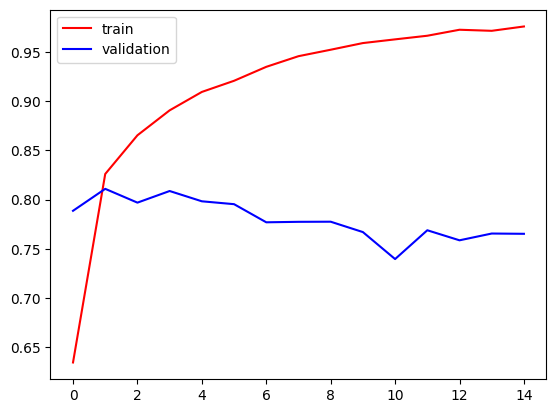

In [51]:
# visulaize the training and validation accuracy for both training and validation data
import matplotlib.pyplot as plt
plt.plot(history.history['acc'], color='red', label='train')
plt.plot(history.history['val_acc'], color='blue', label='validation')
plt.legend()
plt.show()




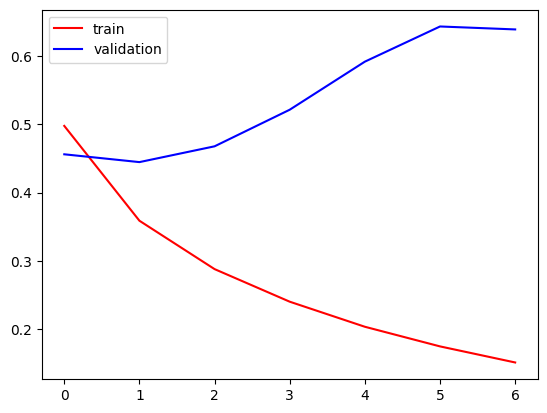

In [39]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()